# Sales Performance Dashboard

This notebook analyzes the **Superstore Sales** dataset to extract key business KPIs and visualizations for:

- Revenue & profit trends over time
- Regional performance comparisons
- Category and sub-category performance
- Customer and segment insights

> **Note:** For a more interactive dashboard experience, these analyses can be imported into **Power BI** and enhanced with slicers, drillthroughs, and dashboard pages.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Helper to load & clean data (safe to call from any cell)
from pathlib import Path

def load_data():
    # Try likely relative paths based on notebook working directory
    candidates = [
        Path("dataset/superstore_sales.csv"),
        Path("../dataset/superstore_sales.csv"),
        Path("superstore_sales.csv"),
        Path("../superstore_sales.csv"),
    ]

    for p in candidates:
        if p.exists():
            df = pd.read_csv(p)
            break
    else:
        raise FileNotFoundError(
            f"Could not find superstore_sales.csv; tried: {[str(p) for p in candidates]}"
        )

    # Basic cleaning
    df = df.dropna()
    df.columns = df.columns.str.strip()

    # Basic derived fields
    df["Profit Margin"] = df["Profit"] / df["Sales"]
    df["Sales per Unit"] = df["Sales"] / df["Quantity"]

    return df

# Load and inspect
df = load_data()

df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Ship Mode       9994 non-null   object 
 1   Segment         9994 non-null   object 
 2   Country         9994 non-null   object 
 3   City            9994 non-null   object 
 4   State           9994 non-null   object 
 5   Postal Code     9994 non-null   int64  
 6   Region          9994 non-null   object 
 7   Category        9994 non-null   object 
 8   Sub-Category    9994 non-null   object 
 9   Sales           9994 non-null   float64
 10  Quantity        9994 non-null   int64  
 11  Discount        9994 non-null   float64
 12  Profit          9994 non-null   float64
 13  Profit Margin   9994 non-null   float64
 14  Sales per Unit  9994 non-null   float64
dtypes: float64(5), int64(2), object(8)
memory usage: 1.1+ MB


Ship Mode         0
Segment           0
Country           0
City              0
State             0
Postal Code       0
Region            0
Category          0
Sub-Category      0
Sales             0
Quantity          0
Discount          0
Profit            0
Profit Margin     0
Sales per Unit    0
dtype: int64

In [17]:
# Core KPIs (re-run data load to ensure the notebook is runnable even if cells are executed out-of-order)
df = load_data()

kpis = {
    "Total Sales": df["Sales"].sum(),
    "Total Profit": df["Profit"].sum(),
    "Average Discount": df["Discount"].mean(),
    "Average Profit Margin": df["Profit Margin"].mean(),
    "Total Quantity": df["Quantity"].sum(),
    "Average Sales per Unit": df["Sales per Unit"].mean(),
    "Row Count (Orders)": len(df),
}

# Optional metrics (only if the relevant columns are available)
if "Order ID" in df.columns:
    kpis["Unique Orders"] = df["Order ID"].nunique()
    kpis["Avg Order Value"] = df.groupby("Order ID")["Sales"].sum().mean()

if "Customer ID" in df.columns or "Customer Name" in df.columns:
    cust_col = "Customer ID" if "Customer ID" in df.columns else "Customer Name"
    kpis["Unique Customers"] = df[cust_col].nunique()

for name, value in kpis.items():
    print(f"{name}: {value:,.2f}")

# Store for reuse
kpi_df = pd.DataFrame(list(kpis.items()), columns=["KPI", "Value"])


Total Sales: 2,297,200.86
Total Profit: 286,397.02
Average Discount: 0.16
Average Profit Margin: 0.12
Total Quantity: 37,873.00
Average Sales per Unit: 60.92
Row Count (Orders): 9,994.00


C:\Users\varsh\AppData\Local\Temp\ipykernel_18844\1992786741.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette="coolwarm")


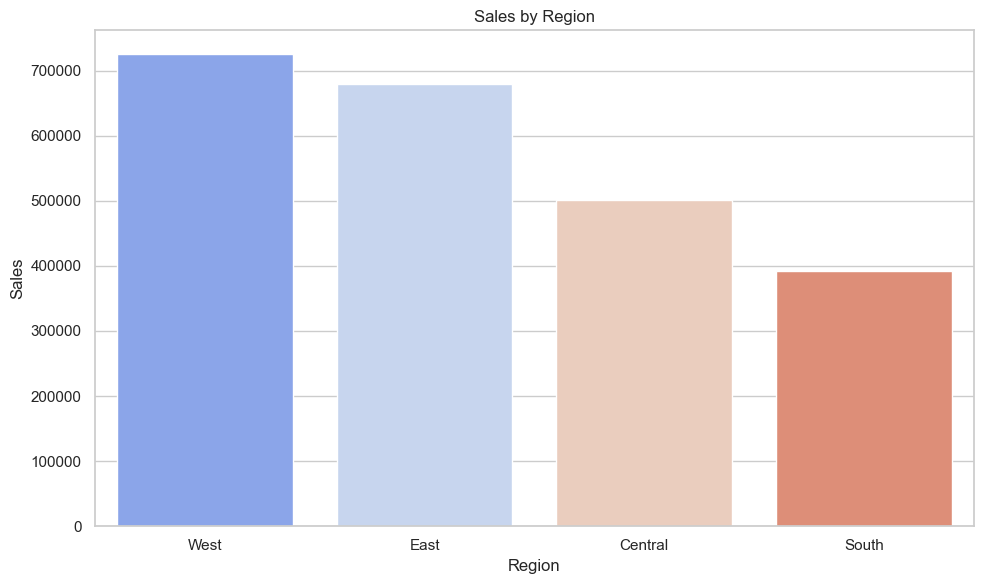

C:\Users\varsh\AppData\Local\Temp\ipykernel_18844\1992786741.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_sales.index, y=segment_sales.values, palette="viridis")


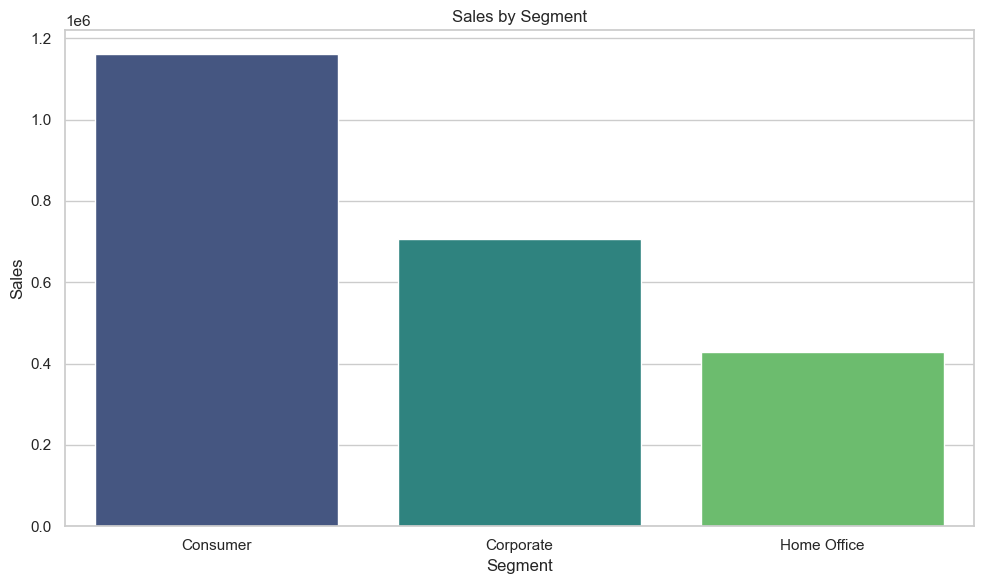

C:\Users\varsh\AppData\Local\Temp\ipykernel_18844\1992786741.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subcat_sales.values, y=subcat_sales.index, palette="magma")


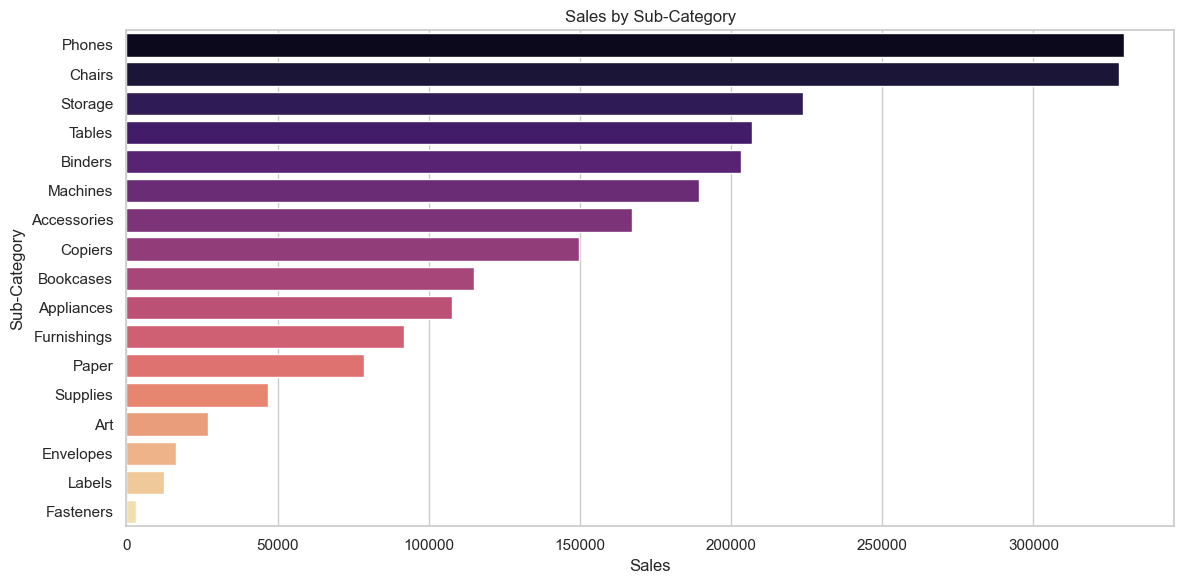

In [18]:
# Region / Segment / Category breakdown

df = load_data()

# Sales by Region
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=region_sales.index, y=region_sales.values, palette="coolwarm")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

# Sales by Segment
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=segment_sales.index, y=segment_sales.values, palette="viridis")
plt.title("Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

# Sales by Sub-Category
subcat_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=subcat_sales.values, y=subcat_sales.index, palette="magma")
plt.title("Sales by Sub-Category")
plt.xlabel("Sales")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()


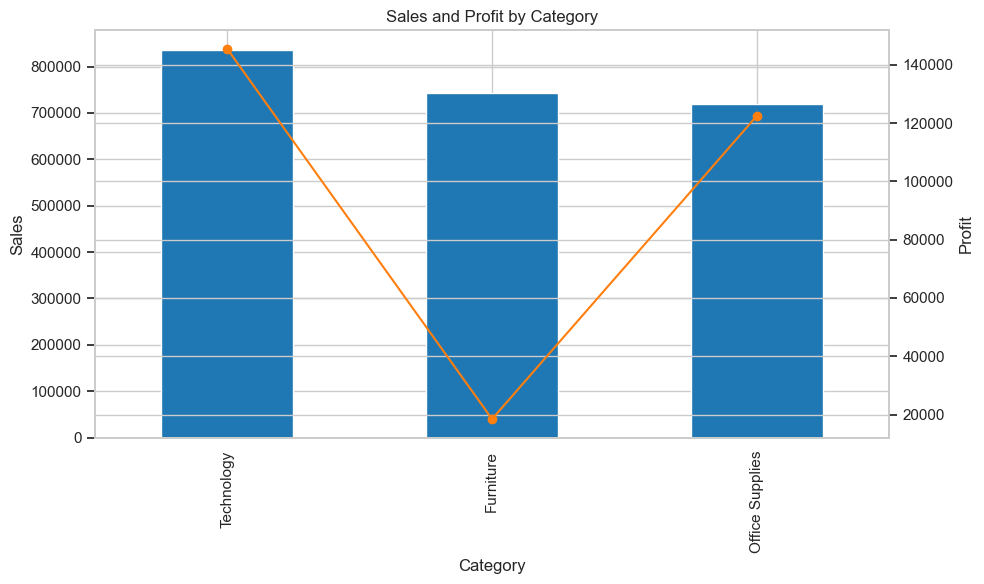

<Figure size 1000x600 with 0 Axes>

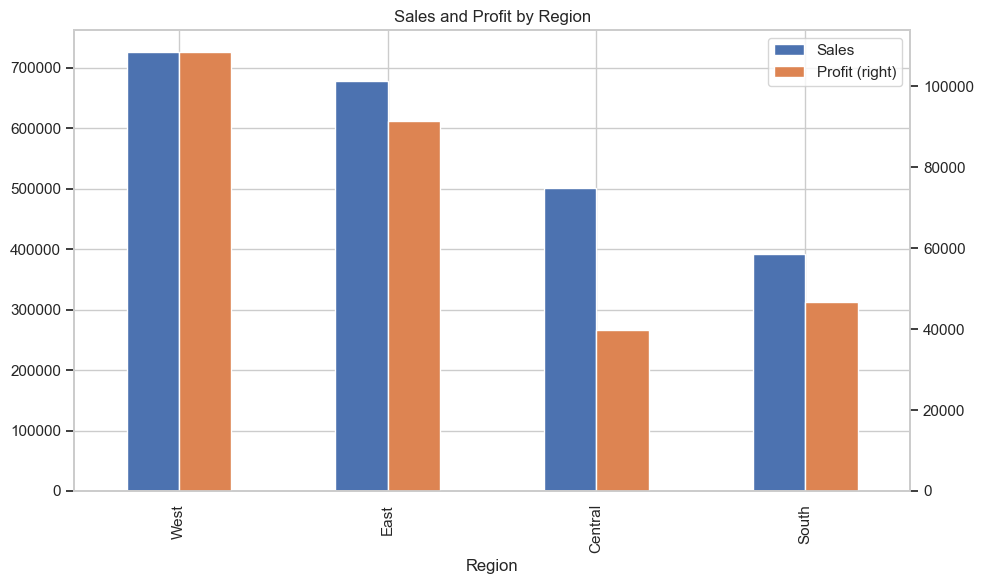

               Sales       Profit  Profit Margin
Region                                          
West     725457.8245  108418.4489       0.149448
East     678781.2400   91522.7800       0.134834
Central  501239.8908   39706.3625       0.079216
South    391721.9050   46749.4303       0.119343


In [19]:
# Category & regional performance

df = load_data()

category_perf = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values(by="Sales", ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 6))
category_perf["Sales"].plot(kind="bar", ax=ax1, color="#1f77b4")
ax1.set_ylabel("Sales")
ax1.set_xlabel("Category")
ax1.set_title("Sales and Profit by Category")

ax2 = ax1.twinx()
category_perf["Profit"].plot(kind="line", marker="o", ax=ax2, color="#ff7f0e")
ax2.set_ylabel("Profit")

plt.tight_layout()
plt.show()

# Regional breakdown
region_perf = df.groupby("Region")[["Sales", "Profit"]].sum()
region_perf["Profit Margin"] = region_perf["Profit"] / region_perf["Sales"]
region_perf.sort_values(by="Sales", ascending=False, inplace=True)

plt.figure(figsize=(10, 6))
region_perf[["Sales", "Profit"]].plot(kind="bar", secondary_y="Profit")
plt.title("Sales and Profit by Region")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

print(region_perf)


C:\Users\varsh\AppData\Local\Temp\ipykernel_18844\1025474804.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_sales.values, y=state_sales.index, palette="crest")


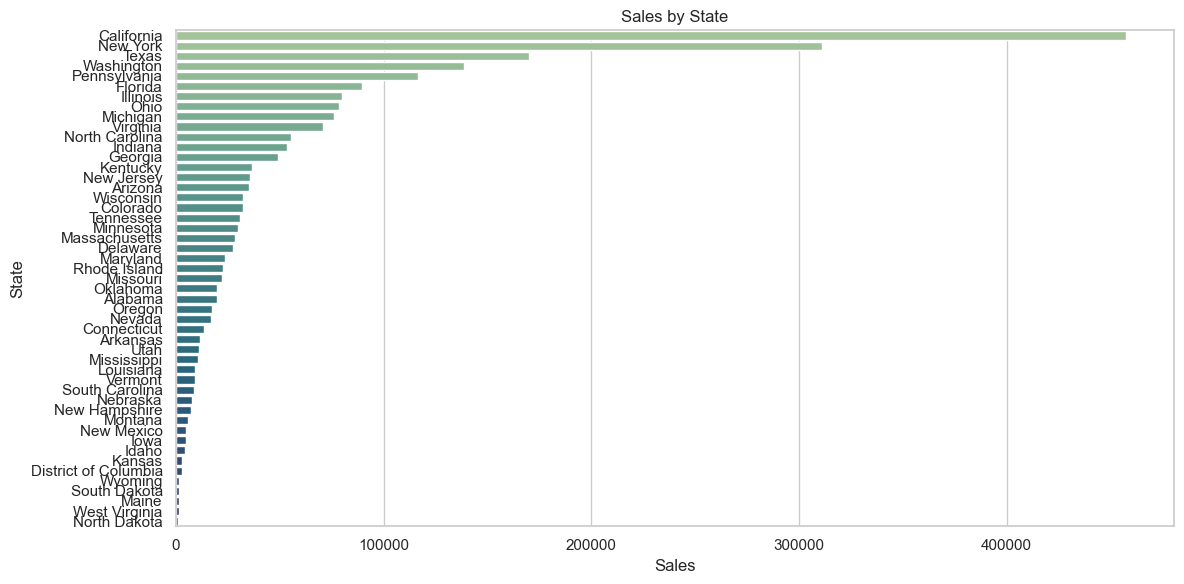

In [20]:
# Top entities and customer-like analysis

df = load_data()

if "Customer Name" in df.columns or "Customer ID" in df.columns:
    customer_col = "Customer Name" if "Customer Name" in df.columns else "Customer ID"
    customer_sales = (
        df.groupby(customer_col)[["Sales", "Profit"]]
        .sum()
        .sort_values(by="Sales", ascending=False)
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(x=customer_sales.head(10)["Sales"], y=customer_sales.head(10).index, palette="magma")
    plt.title("Top 10 Customers by Sales")
    plt.xlabel("Sales")
    plt.ylabel("Customer")
    plt.tight_layout()
    plt.show()

    if "Order ID" in df.columns:
        customer_orders = df.groupby(customer_col)["Order ID"].nunique().sort_values(ascending=False)
        print("Top customers by number of unique orders (repeat buyers):")
        print(customer_orders.head(10))
else:
    # Fallback analysis when customer/order identifiers are not available
    state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=state_sales.values, y=state_sales.index, palette="crest")
    plt.title("Sales by State")
    plt.xlabel("Sales")
    plt.ylabel("State")
    plt.tight_layout()
    plt.show()


In [ ]:
# Export cleaned/enriched dataset for Power BI (optional)

df = load_data()

cleaned_path = "dataset/superstore_sales_cleaned.csv"
df.to_csv(cleaned_path, index=False)
print(f"Exported cleaned dataset to: {cleaned_path}")


OSError: Cannot save file into a non-existent directory: '..\dataset'

## Next Steps (Power BI and Reporting)

- **Load this cleaned dataset** into Power BI and create measures for the KPI values above (Total Sales, Profit Margin, Avg Sales per Unit).  
- Add **slicers** for dimensions like Region, Category, Segment, State, and Sub-Category for interactive filtering.  
- Build **dashboard pages**: Executive summary (KPIs), Regional & category analysis, and customer/market segment insights.  
- Use **drillthrough pages** to enable deeper exploration (e.g., click a region to see sub-category or state performance).  

> Tip: Export the cleaned dataset (including derived columns like Profit Margin and Sales per Unit) to a CSV and import it into Power BI as a static source.